<a href="https://colab.research.google.com/github/AbrarYasir01/kmeans-mall-customers/blob/main/220140.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/AbrarYasir01/kmeans-mall-customers.git
%cd kmeans-mall-customers

Cloning into 'kmeans-mall-customers'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 27 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 10.36 KiB | 2.59 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/kmeans-mall-customers


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [3]:
# Load standard Mall Customers dataset from the repo
mall_df = pd.read_csv("dataset/Mall_Customers.csv")

# Show first few rows to confirm columns
print(mall_df.head())
print("\nColumns:", mall_df.columns.tolist())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [4]:
# Select the three numeric features for clustering
feature_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = mall_df[feature_cols]

# Quick statistics to inspect the feature ranges
print(X.describe())

              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.000000               73.000000
max     70.000000          137.000000               99.000000


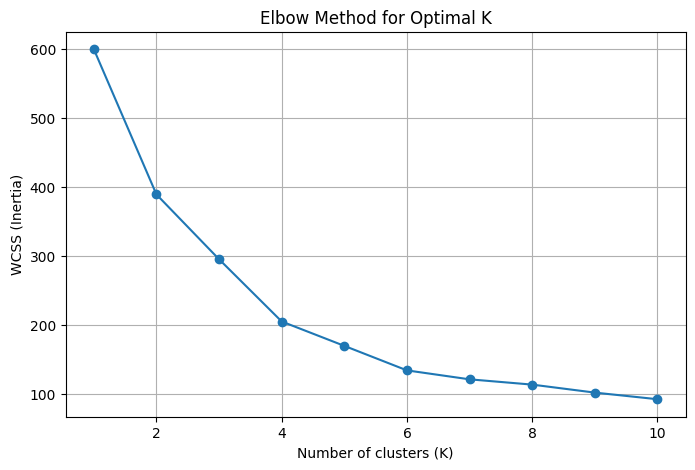

In [5]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=k, random_state=42, n_init="auto"))
    ])
    model.fit(X)
    # inertia_ is the within-cluster sum of squares
    wcss.append(model.named_steps["kmeans"].inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.grid(True)
plt.show()

In [7]:
optimal_k = 6

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=optimal_k, random_state=42, n_init="auto"))
])

# Fit pipeline on the full standard dataset
pipeline.fit(X)

# Add cluster labels back to the original DataFrame
mall_df["Cluster"] = pipeline.predict(X)

mall_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,5
3,4,Female,23,16,77,2
4,5,Female,31,17,40,5


In [8]:
model_path = "model/220140.pkl"
joblib.dump(pipeline, model_path)
print(f"Model saved to {model_path}")

Model saved to model/220140.pkl


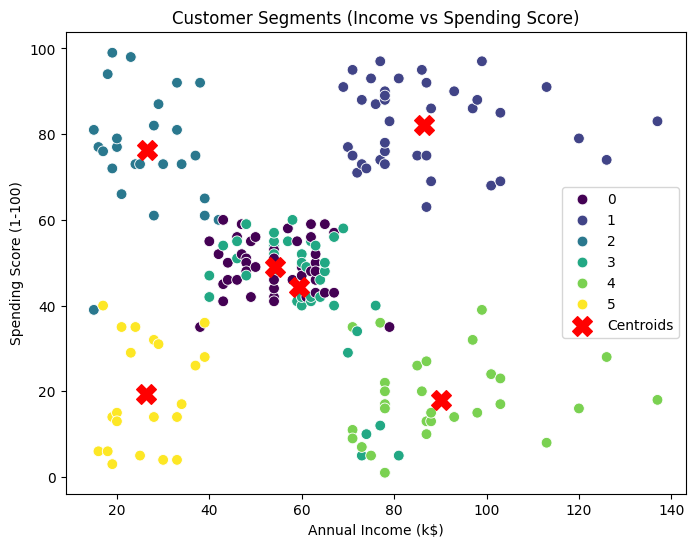

In [9]:
# Get scaler and kmeans parts from the pipeline
scaler = pipeline.named_steps["scaler"]
kmeans = pipeline.named_steps["kmeans"]

# Transform X to scaled space and get centroids
X_scaled = scaler.transform(X)
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=mall_df["Annual Income (k$)"],
    y=mall_df["Spending Score (1-100)"],
    hue=mall_df["Cluster"],
    palette="viridis",
    s=60
)

plt.scatter(
    centroids[:, 1],  # Annual Income
    centroids[:, 2],  # Spending Score
    s=200,
    c="red",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segments (Income vs Spending Score)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [10]:
# Load your custom data
custom_df = pd.read_csv("dataset/custom_customers.csv")

# Ensure columns are in the same order as training
custom_X = custom_df[feature_cols]

# Predict cluster for each of the 10 custom customers
custom_clusters = pipeline.predict(custom_X)

custom_df["Cluster"] = custom_clusters

custom_df

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,2
1,21,15,81,2
2,20,16,6,5
3,23,16,77,2
4,31,17,40,5
5,22,17,76,2
6,35,18,6,5
7,23,18,94,2
8,64,19,3,5
9,30,19,72,2


In [11]:
# Create a DataFrame of centroids for interpretation
centroids_df = pd.DataFrame(
    centroids,
    columns=feature_cols
)
centroids_df["Cluster"] = range(optimal_k)
centroids_df

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,56.333333,54.266667,49.066667,0
1,32.692308,86.538462,82.128205,1
2,25.560000,26.480000,76.240000,2
3,26.125000,59.425000,44.450000,3
4,44.000000,90.133333,17.933333,4
5,45.523810,26.285714,19.380952,5


### Cluster Interpretation

Based on the centroids of each cluster, we can describe the customer groups as follows:

- **Cluster 1**: Young adults with high income and very high spending scores. This segment represents premium, high‑value customers who spend a lot.
- **Cluster 2**: Young customers with low to medium income but high spending scores. These are enthusiastic spenders despite modest income levels.
- **Cluster 3**: Young adults with medium income and average spending scores. This group appears to be moderate, middle‑segment customers.

- **Cluster 0**: Older customers with medium income and moderate spending scores. They are relatively mature shoppers with balanced spending behavior.
- **Cluster 4**: Middle‑aged to older customers with high income but very low spending scores. This cluster may represent wealthy but conservative or low‑engagement shoppers.
- **Cluster 5**: Middle‑aged customers with low income and low spending scores. This segment likely consists of budget‑constrained or infrequent shoppers.